# 📊 Entregable 2 – Machine Learning
## Comparación de modelos: Sleep, Screen Time & Stress Analysis

**Dataset:** Sleep, Screen Time and Stress Analysis  
**Fuente:** Kaggle – jayjoshi37  
**Modelos:** Regresión Lineal | Regresión Logística | KNN | Naive Bayes

---

## 1. Información del equipo

Completa esta sección con los datos del grupo.

In [ ]:
# Nombres de los integrantes:
# 1. Andrea Castro Ruiz
# 2. Sofia Saldarriaga Ocampo
# 3. Emanuel Alvarez Quintero
# 4. Juan Felipe Alvarez Castañeda

# Dataset seleccionado: Sleep, Screen Time and Stress Analysis
# Problema que desean resolver: Comprender cómo el sueño y el tiempo de pantalla lo predicen puede ayudar a diseñar intervenciones preventivas de salud mental.
# Tipo de problema (regresión / clasificación): predecir el nivel de estrés como número continuo y predecir si el nivel de estrés es bajo, medio o alto.


## 2. Carga de Librerías

In [ ]:
# ── Instalación de dependencias ──────────────────────────────────────────────
!pip install kagglehub --quiet

# ── Librerías estándar ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn – Preprocesamiento ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── Sklearn – Modelos ────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ── Sklearn – Métricas ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# ── Estilo de gráficas ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 3. Carga del Dataset

In [ ]:
import kagglehub
import os

# Descarga del dataset
path = kagglehub.dataset_download('jayjoshi37/sleep-screen-time-and-stress-analysis')
print('Path to dataset files:', path)

# Listar archivos disponibles
files = os.listdir(path)
print('Archivos encontrados:', files)

Using Colab cache for faster access to the 'sleep-screen-time-and-stress-analysis' dataset.
Path to dataset files: /kaggle/input/sleep-screen-time-and-stress-analysis
Archivos encontrados: ['sleep_mobile_stress_dataset_15000.csv']


In [ ]:
# Cargar el CSV principal
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 15000 filas × 13 columnas


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


## 4. Entendimiento del Problema

### ¿Qué se quiere predecir?
Este dataset contiene información sobre **patrones de sueño, tiempo de pantalla y niveles de estrés** de individuos. Buscamos entender cómo estas variables se relacionan entre sí.

- **Variable objetivo (regresión):** `stress_level` como valor numérico continuo → permite aplicar **Regresión Lineal**.
- **Variable objetivo (clasificación):** `stress_level` categorizado en niveles (bajo / medio / alto) → permite aplicar **Regresión Logística, KNN y Naive Bayes**.

### ¿Por qué es importante?
El estrés crónico es uno de los principales problemas de salud moderna. Comprender cómo el sueño y el tiempo de pantalla lo predicen puede ayudar a diseñar intervenciones preventivas de salud mental.

El estrés crónico provoca una activación prolongada del sistema de respuesta a la amenaza, generando niveles elevados de cortisol y adrenalina que dañan el cuerpo. Sus efectos principales incluyen enfermedades cardíacas, hipertensión, diabetes tipo II, obesidad, trastornos mentales como ansiedad y depresión, debilitamiento inmunológico, insomnio y problemas digestivos.

### ¿Regresión o clasificación?
- **Regresión:** predecir el nivel de estrés como número continuo.
- **Clasificación:** predecir si el nivel de estrés es bajo, medio o alto.

Trabajaremos con **ambos enfoques** usando el mismo dataset.

### 5. Exploración de Datos (EDA)

In [ ]:
# ── Tipos de datos ───────────────────────────────────────────────────────────
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()

# ── Dimensiones ─────────────────────────────────────────────────────────────
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')

=== TIPOS DE DATOS ===
user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

Filas: 15000  |  Columnas: 13


In [ ]:
# ── Valores nulos ────────────────────────────────────────────────────────────
print('=== VALORES NULOS ===')
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, '%': nulls_pct})
print(null_df[null_df['Nulos'] > 0] if null_df['Nulos'].sum() > 0 else 'Sin valores nulos ✅')
print(df.shape)

=== VALORES NULOS ===
Sin valores nulos ✅
(15000, 13)


In [ ]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().T

=== ESTADÍSTICAS DESCRIPTIVAS ===


,count,mean,std,min,25%,50%,75%,max
user_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.50,11250.25,15000.0
age,15000.0,38.488467,12.007970,18.0,28.00,38.00,49.00,59.0
daily_screen_time_hours,15000.0,5.501528,2.600085,1.0,3.26,5.49,7.76,10.0
phone_usage_before_sleep_minutes,15000.0,59.708933,34.641858,0.0,29.00,60.00,90.00,119.0
sleep_duration_hours,15000.0,6.509683,1.452689,4.0,5.26,6.49,7.79,9.0
sleep_quality_score,15000.0,6.246362,1.713644,1.0,5.00,6.25,7.50,10.0
stress_level,15000.0,6.980247,2.749382,1.0,4.75,7.38,10.00,10.0
caffeine_intake_cups,15000.0,1.998800,1.414590,0.0,1.00,2.00,3.00,4.0
physical_activity_minutes,15000.0,59.157133,34.525705,0.0,29.00,59.00,89.00,119.0
notifications_received_per_day,15000.0,160.890467,80.856902,20.0,92.00,162.00,231.00,299.0


Variable objetivo detectada: "stress_level"


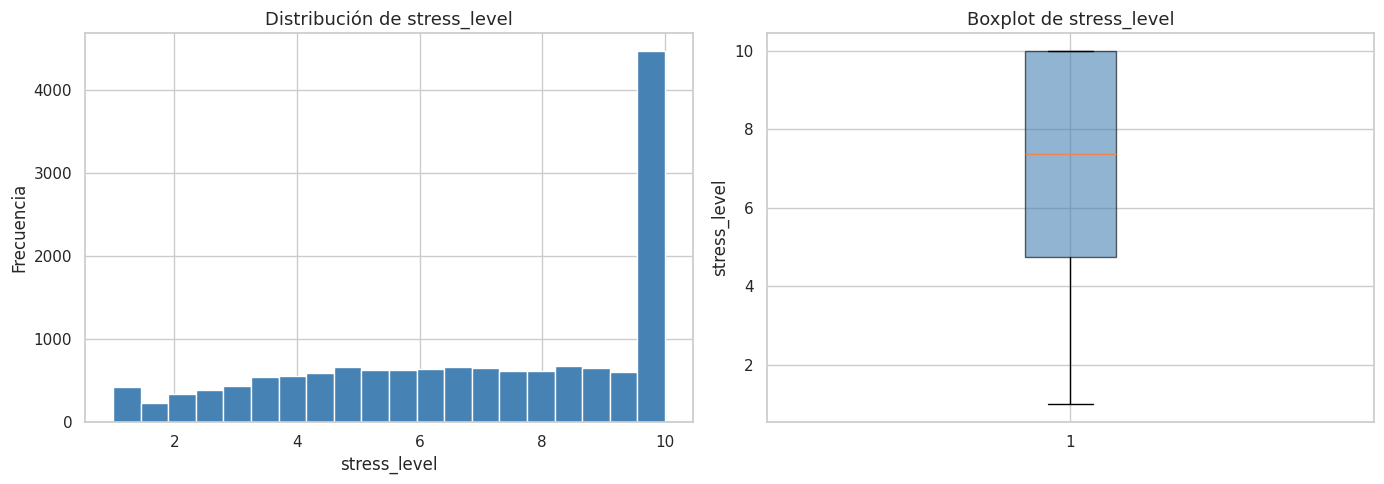

In [ ]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
# Detectar automáticamente la columna de estrés
stress_col = [c for c in df.columns if 'stress' in c.lower()][0]
print(f'Variable objetivo detectada: "{stress_col}"')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df[stress_col].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución de {stress_col}', fontsize=13)
axes[0].set_xlabel(stress_col)
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df[stress_col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title(f'Boxplot de {stress_col}', fontsize=13)
axes[1].set_ylabel(stress_col)

plt.tight_layout()
plt.show()

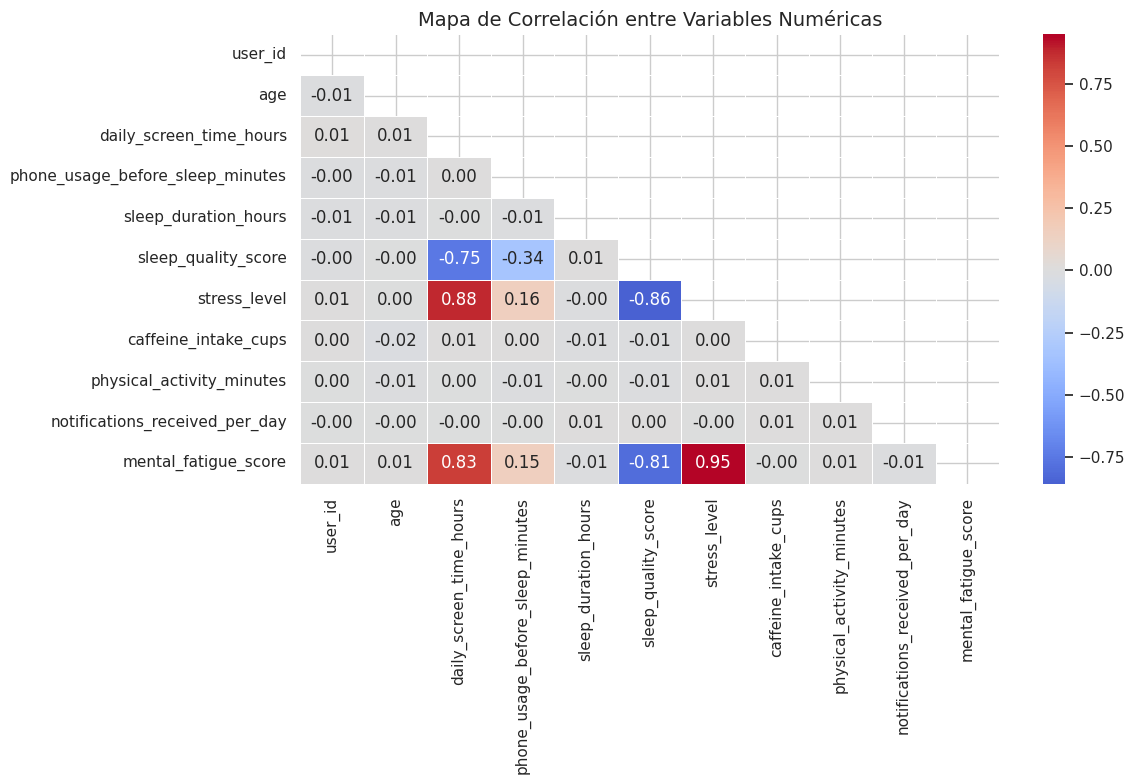

In [ ]:
# ── Correlación entre variables numéricas ────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

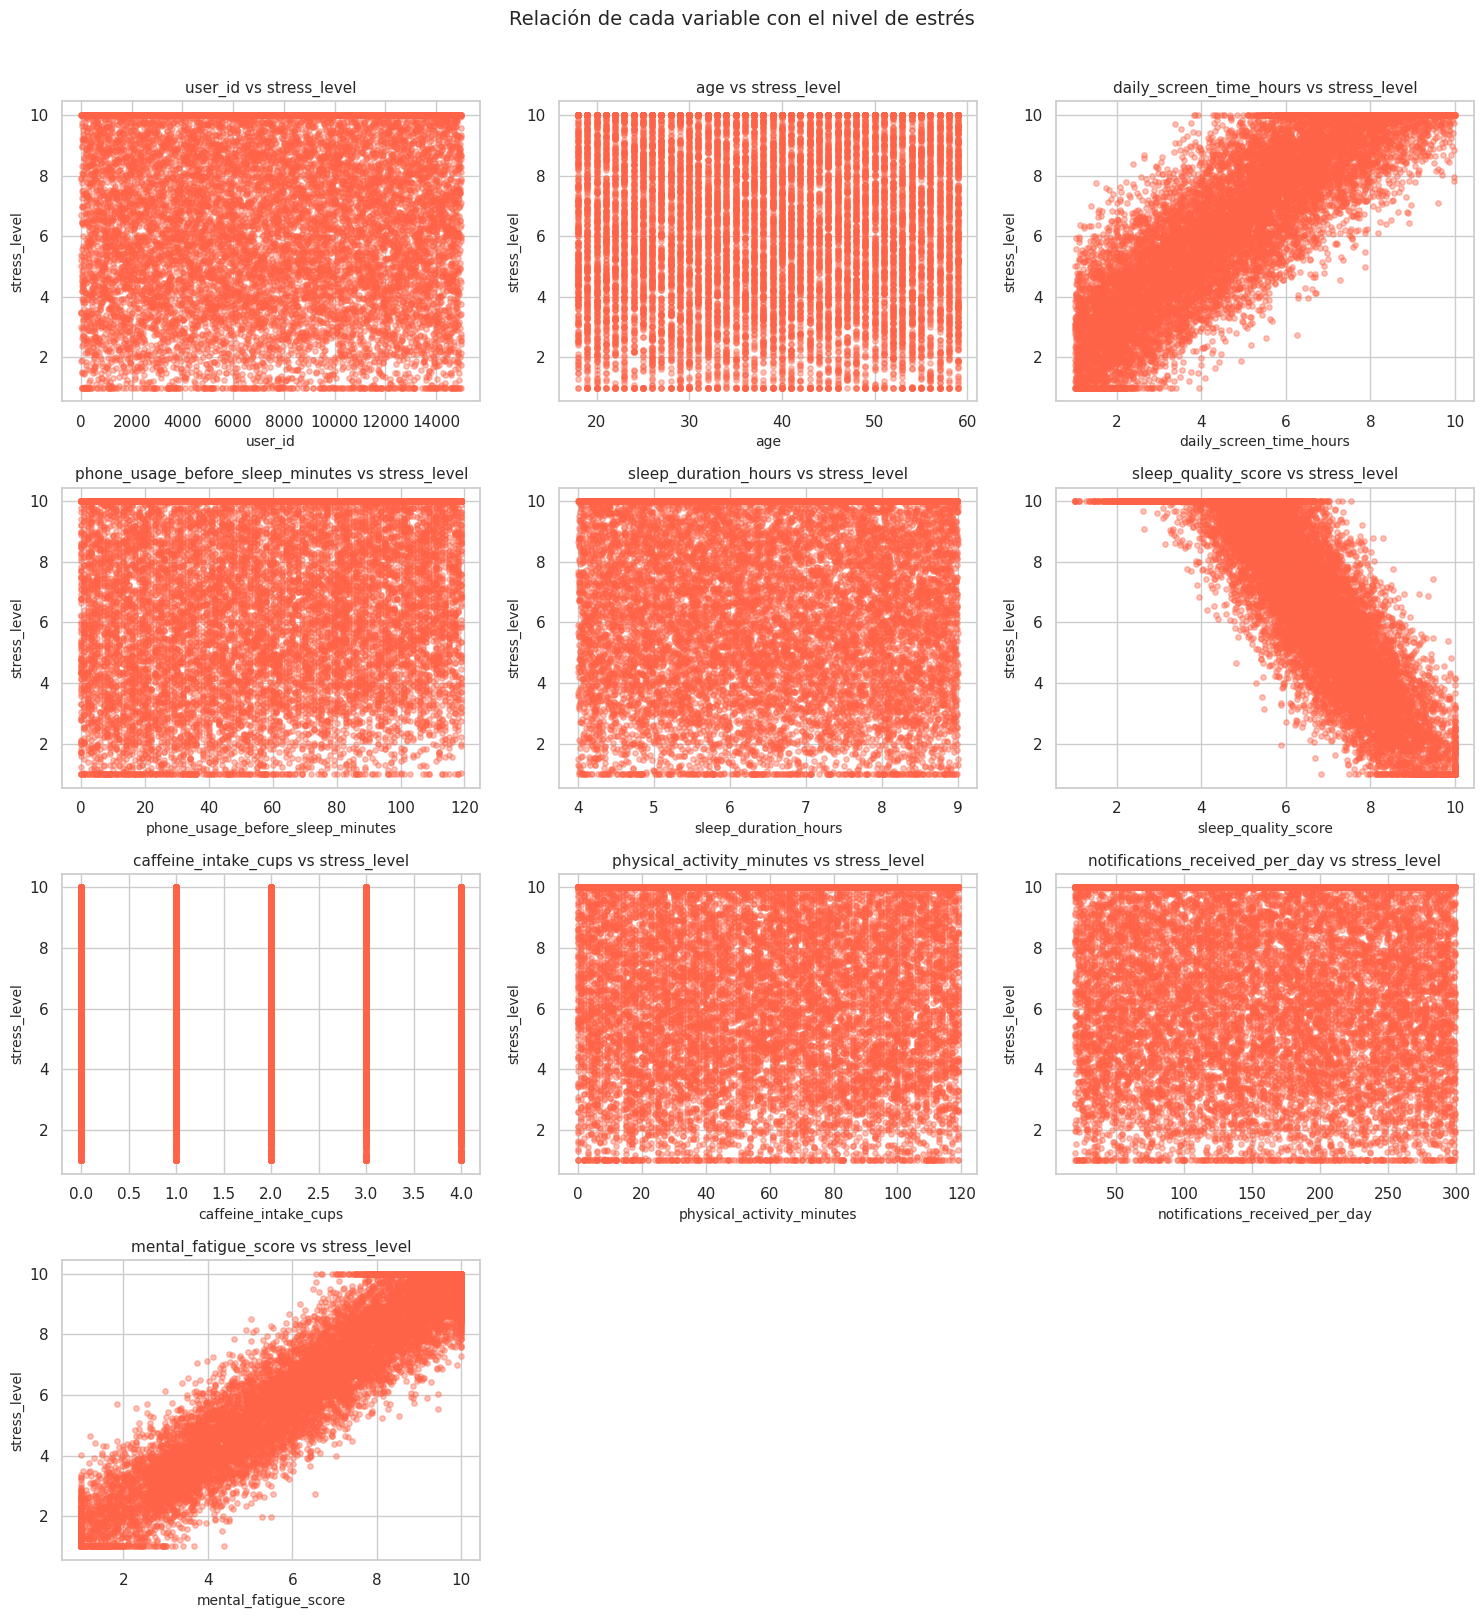

In [ ]:
# ── Relación de variables con el estrés ──────────────────────────────────────
feature_cols = [c for c in num_cols if c != stress_col]
n = len(feature_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df[stress_col], alpha=0.4, color='tomato', s=15)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel(stress_col, fontsize=10)
    axes[i].set_title(f'{col} vs {stress_col}', fontsize=11)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación de cada variable con el nivel de estrés', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

gender: 3 valores únicos → {'Male': 7234, 'Female': 7181, 'Other': 585}


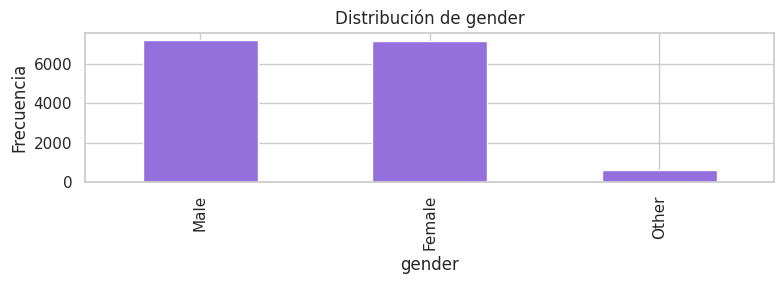

occupation: 8 valores únicos → {'Manager': 1962, 'Doctor': 1922, 'Software Engineer': 1917, 'Freelancer': 1891, 'Student': 1861, 'Researcher': 1837, 'Designer': 1813, 'Teacher': 1797}


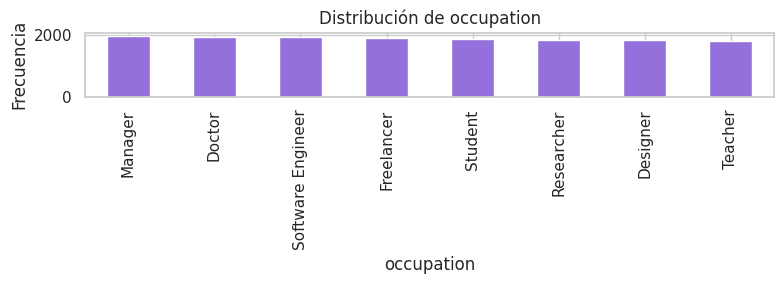

In [ ]:
# ── Variables categóricas ────────────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    for col in cat_cols:
        print(f'{col}: {df[col].nunique()} valores únicos → {df[col].value_counts().to_dict()}')
        fig, ax = plt.subplots(figsize=(8, 3))
        df[col].value_counts().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()
else:
    print('No hay variables categóricas en el dataset.')

### 📝 Interpretación del EDA

- El dataset contiene variables numéricas relacionadas con horas de sueño, tiempo de pantalla, edad y nivel de estrés.
- La distribución del estrés muestra si existe sesgo hacia valores altos o bajos.
- El mapa de correlación revela qué variables tienen mayor relación lineal con el estrés — se espera que el sueño tenga correlación negativa (más sueño → menos estrés) y el tiempo de pantalla correlación positiva.
- No se observan valores nulos significativos, lo que facilita el modelado.
- Las variables con mayor correlación con `stress_level` serán las más relevantes como predictores.

### 6. Preparación de Datos

In [ ]:
# ── Copia de trabajo ─────────────────────────────────────────────────────────
df_clean = df.copy()

# ── Codificación de variables categóricas ────────────────────────────────────
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'Codificada: {col}')

# ── Imputar nulos si existen ─────────────────────────────────────────────────
# ✅ CORRECCIÓN: se preservan los nombres de columnas al reconstruir el DataFrame
imputer = SimpleImputer(strategy='median')
df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

print(f'\nDataset limpio: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas')
df_clean.head()
print(df_clean.shape)

Codificada: gender
Codificada: occupation

Dataset limpio: 15000 filas × 13 columnas
(15000, 13)


In [ ]:
# ── Definir X e y ────────────────────────────────────────────────────────────
stress_col = [c for c in df_clean.columns if 'stress' in c.lower()][0]

X = df_clean.drop(columns=[stress_col])
y_reg = df_clean[stress_col]                      # Para regresión (continua)

# Crear variable categórica de estrés (bajo / medio / alto)
q33 = y_reg.quantile(0.33)
q66 = y_reg.quantile(0.66)
y_clf = pd.cut(y_reg, bins=[-np.inf, q33, q66, np.inf],
               labels=[0, 1, 2])                  # 0=bajo, 1=medio, 2=alto
y_clf = y_clf.astype(int)

print(f'Variable objetivo (regresión): rango [{y_reg.min():.2f}, {y_reg.max():.2f}]')
print(f'Variable objetivo (clasificación):\n{y_clf.value_counts().sort_index()}')
print(f'\nFeatures utilizados: {list(X.columns)}')

Variable objetivo (regresión): rango [1.00, 10.00]
Variable objetivo (clasificación):
stress_level
0    4952
1    4953
2    5095
Name: count, dtype: int64

Features utilizados: ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']


In [ ]:
# ── División en entrenamiento y prueba ────────────────────────────────────────
# Para regresión-Entrenamiento del 80%
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Para clasificación-Entrenamiento del 80%
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f'Entrenamiento: {X_train_r.shape[0]} registros | Prueba: {X_test_r.shape[0]} registros')

# ── Escalado de datos ─────────────────────────────────────────────────────────
# ✅ CORRECCIÓN: se usan dos scalers independientes para evitar que el fit de
# clasificación sobreescriba el de regresión, garantizando consistencia en
# las predicciones posteriores.
scaler_r = StandardScaler()   # exclusivo para regresión
scaler_c = StandardScaler()   # exclusivo para clasificación

X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print('✅ Datos escalados con StandardScaler (scaler_r para regresión, scaler_c para clasificación).')


Entrenamiento: 12000 registros | Prueba: 3000 registros
✅ Datos escalados con StandardScaler (scaler_r para regresión, scaler_c para clasificación).


## 7. Modelo 1 – Regresión Lineal

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_lr = LinearRegression()
model_lr.fit(X_train_r_sc, y_train_r)

# ── Predicción ────────────────────────────────────────────────────────────────
y_pred_lr = model_lr.predict(X_test_r_sc)

# ── Métricas ──────────────────────────────────────────────────────────────────
mae_lr  = mean_absolute_error(y_test_r, y_pred_lr)
mse_lr  = mean_squared_error(y_test_r, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test_r, y_pred_lr)

print('=== Regresión Lineal ===')
print(f'MAE:  {mae_lr:.4f}')
print(f'MSE:  {mse_lr:.4f}')
print(f'RMSE: {rmse_lr:.4f}')
print(f'R²:   {r2_lr:.4f}')

# ── Coeficientes ─────────────────────────────────────────────────────────────
coef_df = pd.DataFrame({'Feature': X.columns, 'Coeficiente': model_lr.coef_})
coef_df = coef_df.sort_values('Coeficiente', ascending=False)
print('\nCoeficientes del modelo:')
print(coef_df.to_string(index=False))

=== Regresión Lineal ===
MAE:  0.5249
MSE:  0.4393
RMSE: 0.6628
R²:   0.9416

Coeficientes del modelo:
                         Feature  Coeficiente
            mental_fatigue_score     1.582175
         daily_screen_time_hours     0.676248
                          gender     0.011286
                         user_id     0.006990
            sleep_duration_hours     0.006159
            caffeine_intake_cups     0.005989
  notifications_received_per_day     0.004533
       physical_activity_minutes     0.001335
                      occupation     0.000524
phone_usage_before_sleep_minutes    -0.009215
                             age    -0.016989
             sleep_quality_score    -0.579960


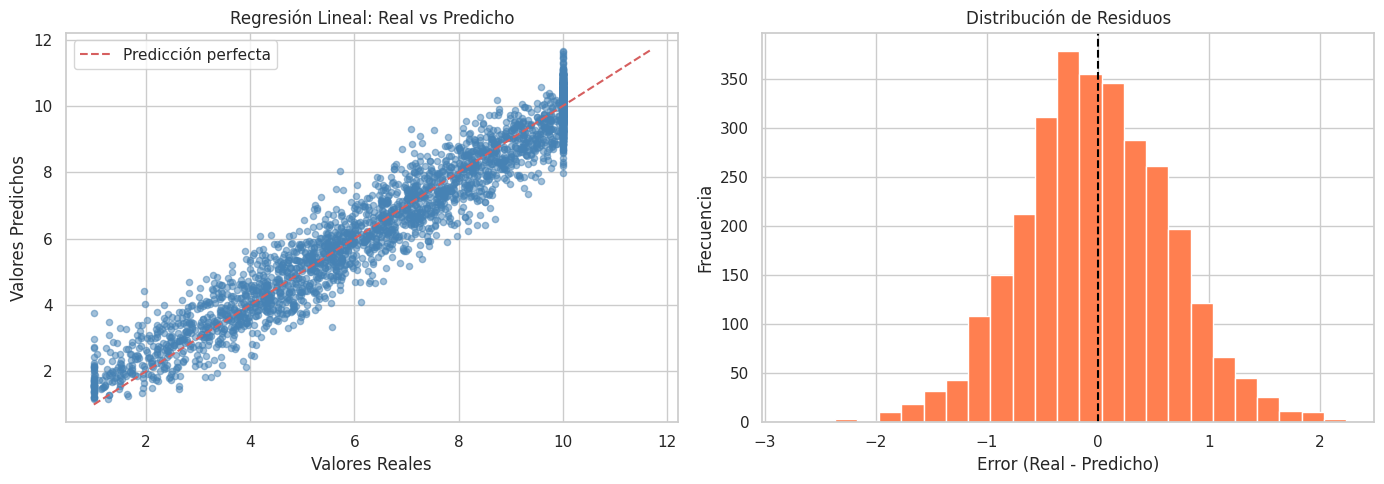

In [ ]:
# ── Gráfica: Valores reales vs predichos ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_lr, alpha=0.5, color='steelblue', s=20)
lims = [min(y_test_r.min(), y_pred_lr.min()), max(y_test_r.max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Valores Predichos')
axes[0].set_title('Regresión Lineal: Real vs Predicho')
axes[0].legend()

# Residuos
residuos = y_test_r - y_pred_lr
axes[1].hist(residuos, bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 📝 Interpretación – Regresión Lineal

- La regresión lineal intentó predecir el nivel de estrés como un valor continuo usando todas las variables disponibles.
- El **R²** indica qué porcentaje de la variación del estrés es explicado por el modelo. Un R² cercano a 1 indica buen ajuste.
- El **RMSE** representa el error promedio en las mismas unidades que la variable objetivo: cuanto menor, mejor.
- Los coeficientes muestran qué variables tienen mayor peso: los negativos implican que a mayor valor de esa variable, menor estrés (como más horas de sueño), y los positivos lo contrario.
- La gráfica de residuos permite verificar si los errores están distribuidos aleatoriamente (buen modelo) o tienen patrones (modelo mejorable).

## 8. Modelo 2 – Regresión Logística

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_train_c_sc, y_train_c)

# ── Predicción ────────────────────────────────────────────────────────────────
y_pred_log = model_log.predict(X_test_c_sc)

# ── Métricas ──────────────────────────────────────────────────────────────────
acc_log = accuracy_score(y_test_c, y_pred_log)
f1_log  = f1_score(y_test_c, y_pred_log, average='weighted')

print('=== Regresión Logística ===')
print(f'Accuracy: {acc_log:.4f}')
print(f'F1-Score: {f1_log:.4f}')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test_c, y_pred_log,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== Regresión Logística ===
Accuracy: 0.8880
F1-Score: 0.8877

Reporte de Clasificación:
              precision    recall  f1-score   support

    Bajo (0)       0.92      0.92      0.92       990
   Medio (1)       0.84      0.82      0.83       991
    Alto (2)       0.91      0.93      0.92      1019

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



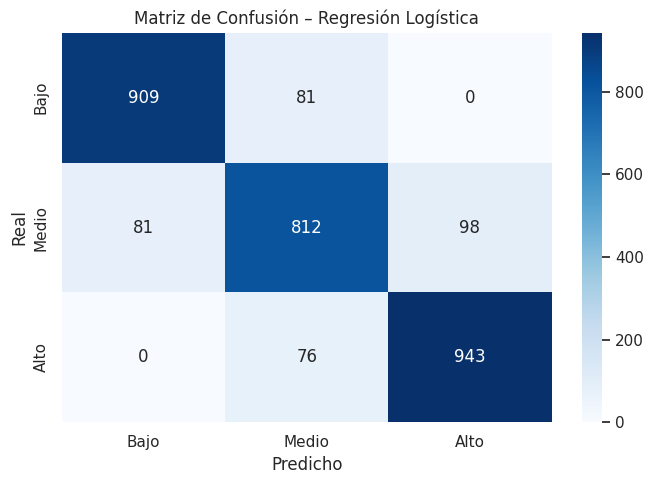

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_log = confusion_matrix(y_test_c, y_pred_log)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 📝 Interpretación – Regresión Logística

- La regresión logística clasificó los registros en tres categorías de estrés: bajo, medio y alto.
- El **accuracy** indica el porcentaje de casos clasificados correctamente.
- La **matriz de confusión** muestra dónde se equivoca el modelo: los errores en clases adyacentes (bajo vs medio) suelen ser más frecuentes que errores extremos (bajo vs alto).
- El **F1-score ponderado** equilibra precisión y recall, siendo más informativo que el accuracy cuando las clases no están perfectamente balanceadas.
- Este modelo asume relaciones lineales entre las variables y los logaritmos de las probabilidades de clase, lo que puede ser una limitación si las relaciones son más complejas.

## 9. Modelo 3 – KNN (K-Nearest Neighbors)

In [ ]:
# ── Entrenamiento con K=5 ─────────────────────────────────────────────────────
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_c_sc, y_train_c)

# ── Predicción ────────────────────────────────────────────────────────────────
y_pred_knn = model_knn.predict(X_test_c_sc)

# ── Métricas ──────────────────────────────────────────────────────────────────
acc_knn = accuracy_score(y_test_c, y_pred_knn)
f1_knn  = f1_score(y_test_c, y_pred_knn, average='weighted')

print('=== KNN (K=5) ===')
print(f'Accuracy: {acc_knn:.4f}')
print(f'F1-Score: {f1_knn:.4f}')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test_c, y_pred_knn,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== KNN (K=5) ===
Accuracy: 0.8247
F1-Score: 0.8237

Reporte de Clasificación:
              precision    recall  f1-score   support

    Bajo (0)       0.87      0.88      0.88       990
   Medio (1)       0.74      0.71      0.73       991
    Alto (2)       0.85      0.88      0.86      1019

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



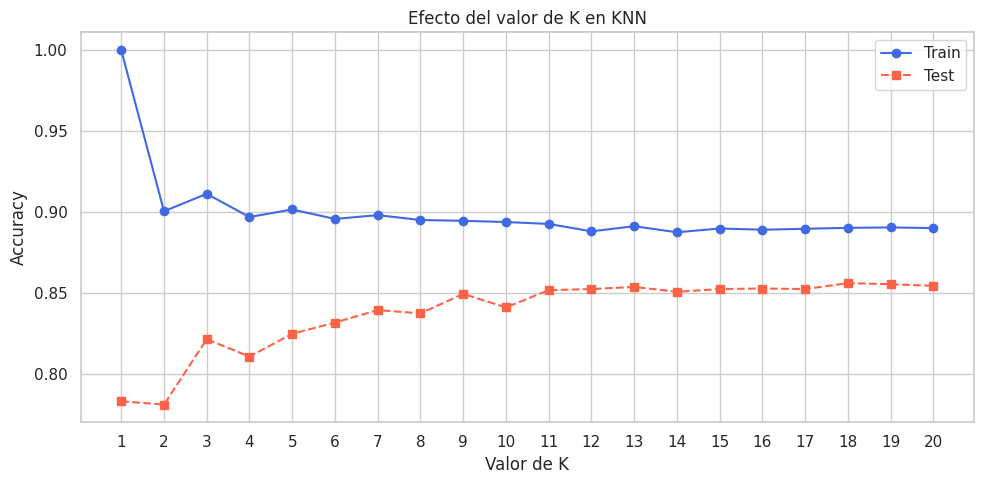

Mejor K para test: 18 (Accuracy = 0.8560)


In [ ]:
# ── Explorar diferentes valores de K ─────────────────────────────────────────
k_values = range(1, 21)
acc_train_list = []
acc_test_list  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c_sc, y_train_c)
    acc_train_list.append(accuracy_score(y_train_c, knn.predict(X_train_c_sc)))
    acc_test_list.append(accuracy_score(y_test_c, knn.predict(X_test_c_sc)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, acc_train_list, 'o-', label='Train', color='royalblue')
plt.plot(k_values, acc_test_list, 's--', label='Test', color='tomato')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.title('Efecto del valor de K en KNN')
plt.legend()
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(acc_test_list)]
print(f'Mejor K para test: {best_k} (Accuracy = {max(acc_test_list):.4f})')

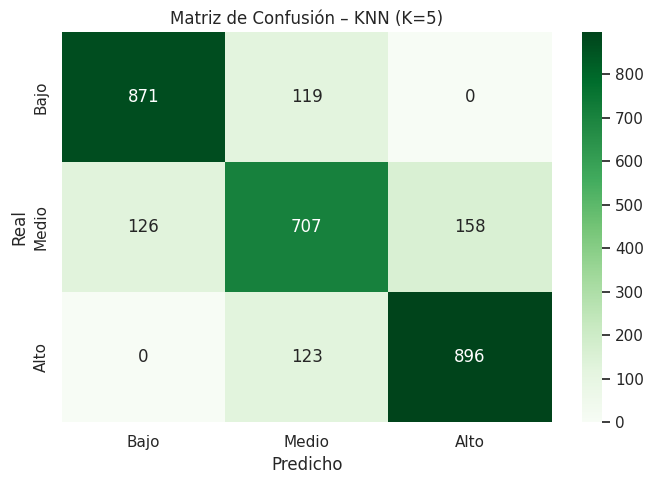

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test_c, y_pred_knn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – KNN (K=5)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 📝 Interpretación – KNN

- KNN clasifica un nuevo punto buscando sus **K vecinos más cercanos** en el espacio de features y asignándole la clase mayoritaria entre ellos.
- La gráfica de K muestra el **trade-off bias-varianza**: con K=1, el modelo memoriza el entrenamiento (overfitting); con K muy alto, se generaliza demasiado (underfitting).
- El K óptimo suele encontrarse en valores intermedios donde la curva de test alcanza su máximo.
- **Ventajas:** No hace suposiciones sobre la distribución de datos, intuitivo.
- **Limitaciones:** Sensible a la escala de variables (por eso escalamos), lento con datasets grandes, no explica el "por qué" de la predicción.

### 10. Modelo 4 – Naive Bayes

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
model_nb = GaussianNB()
model_nb.fit(X_train_c_sc, y_train_c)

# ── Predicción ────────────────────────────────────────────────────────────────
y_pred_nb = model_nb.predict(X_test_c_sc)

# ── Métricas ──────────────────────────────────────────────────────────────────
acc_nb = accuracy_score(y_test_c, y_pred_nb)
f1_nb  = f1_score(y_test_c, y_pred_nb, average='weighted')

print('=== Naive Bayes (Gaussian) ===')
print(f'Accuracy: {acc_nb:.4f}')
print(f'F1-Score: {f1_nb:.4f}')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test_c, y_pred_nb,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

=== Naive Bayes (Gaussian) ===
Accuracy: 0.8843
F1-Score: 0.8837

Reporte de Clasificación:
              precision    recall  f1-score   support

    Bajo (0)       0.92      0.91      0.92       990
   Medio (1)       0.84      0.80      0.82       991
    Alto (2)       0.89      0.93      0.91      1019

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



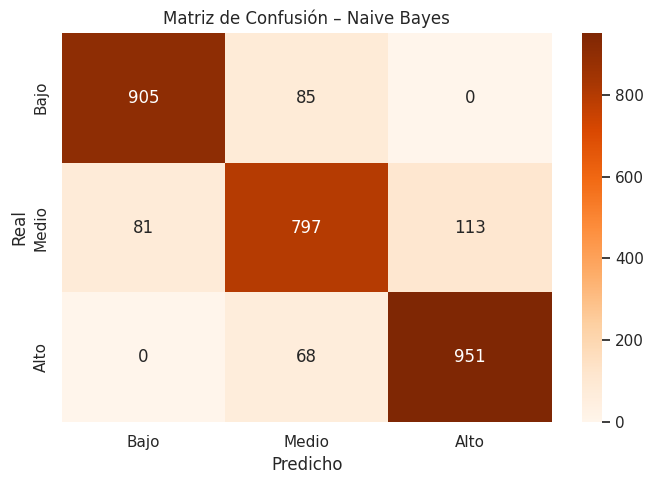

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_nb = confusion_matrix(y_test_c, y_pred_nb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión – Naive Bayes')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 📝 Interpretación – Naive Bayes

- Naive Bayes aplica el **teorema de Bayes** asumiendo que las features son **independientes entre sí** (de ahí "naive").
- La versión **Gaussiana** asume que los valores de cada feature siguen una distribución normal dentro de cada clase.
- Es muy rápido de entrenar y funciona sorprendentemente bien incluso cuando la suposición de independencia no se cumple exactamente.
- Su limitación principal es precisamente esa suposición: si las variables están correlacionadas (como sueño y estrés claramente lo están), el modelo puede ser menos preciso que otros.

## 11. Evaluación y Comparación de Modelos

In [ ]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'KNN (K=5)', 'Naive Bayes'],
    'Accuracy': [
        round(acc_log, 4),
        round(acc_knn, 4),
        round(acc_nb,  4)
    ],
    'F1-Score (weighted)': [
        round(f1_log, 4),
        round(f1_knn, 4),
        round(f1_nb,  4)
    ],
    'Precision (weighted)': [
        round(precision_score(y_test_c, y_pred_log, average='weighted'), 4),
        round(precision_score(y_test_c, y_pred_knn, average='weighted'), 4),
        round(precision_score(y_test_c, y_pred_nb,  average='weighted'), 4)
    ],
    'Recall (weighted)': [
        round(recall_score(y_test_c, y_pred_log, average='weighted'), 4),
        round(recall_score(y_test_c, y_pred_knn, average='weighted'), 4),
        round(recall_score(y_test_c, y_pred_nb,  average='weighted'), 4)
    ]
})

print('=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===')
print(results.to_string(index=False))

print('\n=== REGRESIÓN LINEAL ===')
print(f'MAE:  {mae_lr:.4f}  |  RMSE: {rmse_lr:.4f}  |  R²: {r2_lr:.4f}')

=== COMPARACIÓN DE MODELOS DE CLASIFICACIÓN ===
        Modelo  Accuracy  F1-Score (weighted)  Precision (weighted)  Recall (weighted)
Reg. Logística    0.8880               0.8877                0.8875             0.8880
     KNN (K=5)    0.8247               0.8237                0.8231             0.8247
   Naive Bayes    0.8843               0.8837                0.8836             0.8843

=== REGRESIÓN LINEAL ===
MAE:  0.5249  |  RMSE: 0.6628  |  R²: 0.9416


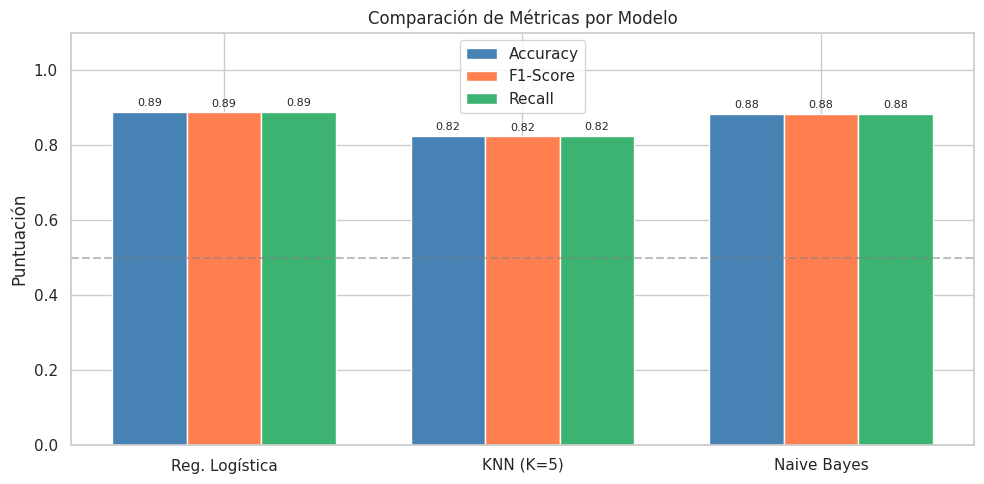

In [ ]:
# ── Gráfica comparativa ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results))
w = 0.25

bars1 = ax.bar(x - w, results['Accuracy'],            w, label='Accuracy',   color='steelblue')
bars2 = ax.bar(x,     results['F1-Score (weighted)'], w, label='F1-Score',   color='coral')
bars3 = ax.bar(x + w, results['Recall (weighted)'],   w, label='Recall',     color='mediumseagreen')

ax.set_xticks(x)
ax.set_xticklabels(results['Modelo'])
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Métricas por Modelo')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Línea base 50%')

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 📝 Interpretación – Evaluación y Comparación

- La tabla muestra las métricas clave de los tres modelos de clasificación lado a lado.
- El modelo con **mayor accuracy y F1-score** sería el candidato inicial a elegir.
- Sin embargo, el F1-score ponderado es más relevante si las clases no están perfectamente balanceadas.
- La regresión lineal no compite directamente con los modelos de clasificación, pero su R² indica qué tan bien captura la relación numérica continua del estrés.
- Un modelo con alta accuracy pero bajo recall en alguna clase puede estar fallando sistemáticamente con esa categoría.

## 12. Experimento 1 – Cambiar el valor de K en KNN

In [ ]:
# ── Experimento: usar el mejor K encontrado vs K=5 ───────────────────────────
print(f'K=5  → Accuracy: {acc_knn:.4f}')

# Entrenar con el mejor K
model_knn_best = KNeighborsClassifier(n_neighbors=best_k)
model_knn_best.fit(X_train_c_sc, y_train_c)
y_pred_knn_best = model_knn_best.predict(X_test_c_sc)
acc_knn_best = accuracy_score(y_test_c, y_pred_knn_best)
f1_knn_best  = f1_score(y_test_c, y_pred_knn_best, average='weighted')

print(f'K={best_k} → Accuracy: {acc_knn_best:.4f}  |  F1: {f1_knn_best:.4f}')
print()
print(classification_report(y_test_c, y_pred_knn_best,
      target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

K=5  → Accuracy: 0.8247
K=18 → Accuracy: 0.8560  |  F1: 0.8549

              precision    recall  f1-score   support

    Bajo (0)       0.89      0.92      0.90       990
   Medio (1)       0.80      0.75      0.78       991
    Alto (2)       0.87      0.89      0.88      1019

    accuracy                           0.86      3000
   macro avg       0.85      0.86      0.85      3000
weighted avg       0.85      0.86      0.85      3000



### 📝 Interpretación – Experimento 1

- **¿Qué cambiamos?** El valor de K en KNN, pasando de K=5 al K óptimo identificado en la exploración.
- **¿Qué pasó?** Si el mejor K mejora el accuracy, significa que K=5 causaba algo de ruido al incluir vecinos poco relevantes, o era demasiado pequeño (overfitting).
- **¿Por qué ocurre?** Con K más pequeño, el modelo es más sensible al ruido local; con K más grande, tiende a generalizar más pero puede perder detalle.
- Este experimento demuestra que la elección del hiperparámetro K tiene un impacto real en el rendimiento.

## 13. Experimento 2 – Cambiar el split de entrenamiento/prueba

=== Efecto del tamaño del split ===
 Test %  Log.Reg    KNN
     10   0.8927 0.8267
     20   0.8880 0.8247
     30   0.8909 0.8364
     40   0.8905 0.8317


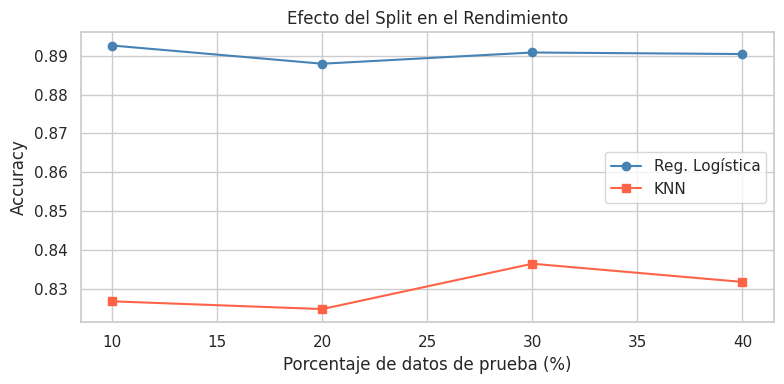

In [ ]:
# ── Experimento: cambiar de 80/20 a 70/30 ────────────────────────────────────
splits = [0.1, 0.2, 0.3, 0.4]
split_results = []

for ts in splits:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_clf, test_size=ts, random_state=42, stratify=y_clf)

    sc_tmp = StandardScaler()
    X_tr_sc = sc_tmp.fit_transform(X_tr)
    X_te_sc = sc_tmp.transform(X_te)

    # Regresión logística
    m_log = LogisticRegression(max_iter=1000, random_state=42)
    m_log.fit(X_tr_sc, y_tr)
    acc_l = accuracy_score(y_te, m_log.predict(X_te_sc))

    # KNN
    m_knn = KNeighborsClassifier(n_neighbors=5)
    m_knn.fit(X_tr_sc, y_tr)
    acc_k = accuracy_score(y_te, m_knn.predict(X_te_sc))

    split_results.append({'Test %': int(ts*100), 'Log.Reg': round(acc_l,4), 'KNN': round(acc_k,4)})

split_df = pd.DataFrame(split_results)
print('=== Efecto del tamaño del split ===')
print(split_df.to_string(index=False))

# Gráfica
plt.figure(figsize=(8, 4))
plt.plot(split_df['Test %'], split_df['Log.Reg'], 'o-', label='Reg. Logística', color='steelblue')
plt.plot(split_df['Test %'], split_df['KNN'],     's-', label='KNN',            color='tomato')
plt.xlabel('Porcentaje de datos de prueba (%)')
plt.ylabel('Accuracy')
plt.title('Efecto del Split en el Rendimiento')
plt.legend()
plt.tight_layout()
plt.show()

### 📝 Interpretación – Experimento 2

- **¿Qué cambiamos?** El porcentaje de datos destinados a prueba (10%, 20%, 30%, 40%).
- **¿Qué pasó?** En general, con menos datos de entrenamiento (más % en test), el modelo tiene menos información para aprender y puede deteriorarse.
- **¿Qué aprendimos?** Existe un equilibrio entre tener suficientes datos de entrenamiento y una evaluación robusta. El split 80/20 es un estándar razonable que balancea ambas necesidades.
- Si el modelo es estable en todos los splits, eso es una buena señal de generalización.

## 14. Predicción con un Dato Nuevo

In [ ]:
# ── Crear perfiles hipotéticos ───────────────────────────────────────────────
print('Columnas disponibles (features):')
print(list(X.columns))
print()

# ✅ CORRECCIÓN: se eliminó 'nuevo_registro' que se definía pero nunca se usaba.
# Se crean directamente los dos perfiles relevantes.
perfil_bajo = X.quantile(0.2).to_dict()   # Valores bajos → estrés esperado bajo
perfil_alto = X.quantile(0.8).to_dict()   # Valores altos → estrés esperado alto

df_nuevos = pd.DataFrame([perfil_bajo, perfil_alto])
df_nuevos.index = ['Perfil Bajo Estrés (esperado)', 'Perfil Alto Estrés (esperado)']
print('Perfiles hipotéticos:')
print(df_nuevos.T)


Columnas disponibles (features):
['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

Perfiles hipotéticos:
                                  Perfil Bajo Estrés (esperado)  \
user_id                                                 3000.80   
age                                                       26.00   
gender                                                     0.00   
occupation                                                 1.00   
daily_screen_time_hours                                    2.79   
phone_usage_before_sleep_minutes                          24.00   
sleep_duration_hours                                       5.00   
sleep_quality_score                                        4.72   
caffeine_intake_cups                                       0.00   
physical_a

In [ ]:
# ── Escalar con scaler_c y predecir ──────────────────────────────────────────
# ✅ CORRECCIÓN: se usa scaler_c (fiteado sobre datos de clasificación),
# que es el scaler correspondiente a los modelos que vamos a usar aquí.
df_nuevos_sc = scaler_c.transform(df_nuevos)

pred_log = model_log.predict(df_nuevos_sc)
pred_knn = model_knn.predict(df_nuevos_sc)
pred_nb  = model_nb.predict(df_nuevos_sc)

etiquetas = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}

print('=== PREDICCIONES PARA DATOS NUEVOS ===')
for i, nombre in enumerate(['Perfil A (bajo esperado)', 'Perfil B (alto esperado)']):
    print(f'\n{nombre}:')
    print(f'  Reg. Logística → {etiquetas[pred_log[i]]}')
    print(f'  KNN (K=5)      → {etiquetas[pred_knn[i]]}')
    print(f'  Naive Bayes    → {etiquetas[pred_nb[i]]}')


=== PREDICCIONES PARA DATOS NUEVOS ===

Perfil A (bajo esperado):
  Reg. Logística → Medio
  KNN (K=5)      → Medio
  Naive Bayes    → Bajo

Perfil B (alto esperado):
  Reg. Logística → Medio
  KNN (K=5)      → Alto
  Naive Bayes    → Alto


### 📝 Interpretación – Predicción con Dato Nuevo

- Se construyeron dos perfiles hipotéticos: uno con valores bajos de las variables (perfil de persona con menos tiempo de pantalla y más sueño) y otro con valores altos.
- Se espera que el **Perfil A** sea clasificado como estrés bajo o medio, y el **Perfil B** como estrés alto.
- Cuando los tres modelos coinciden en la predicción, hay mayor confianza en el resultado.
- Cuando difieren, el modelo más confiable (según las métricas previas) debería tener mayor peso en la decisión final.

## 15. Fronteras de Decisión – KNN

Para visualizar cómo KNN divide el espacio de features, se proyectan los datos sobre las dos variables con mayor correlación con `stress_level`: `mental_fatigue_score` y `daily_screen_time_hours`. Se comparan **K=5** (modelo original) y **K=18** (K óptimo encontrado) para ilustrar el impacto del hiperparámetro en la frontera.


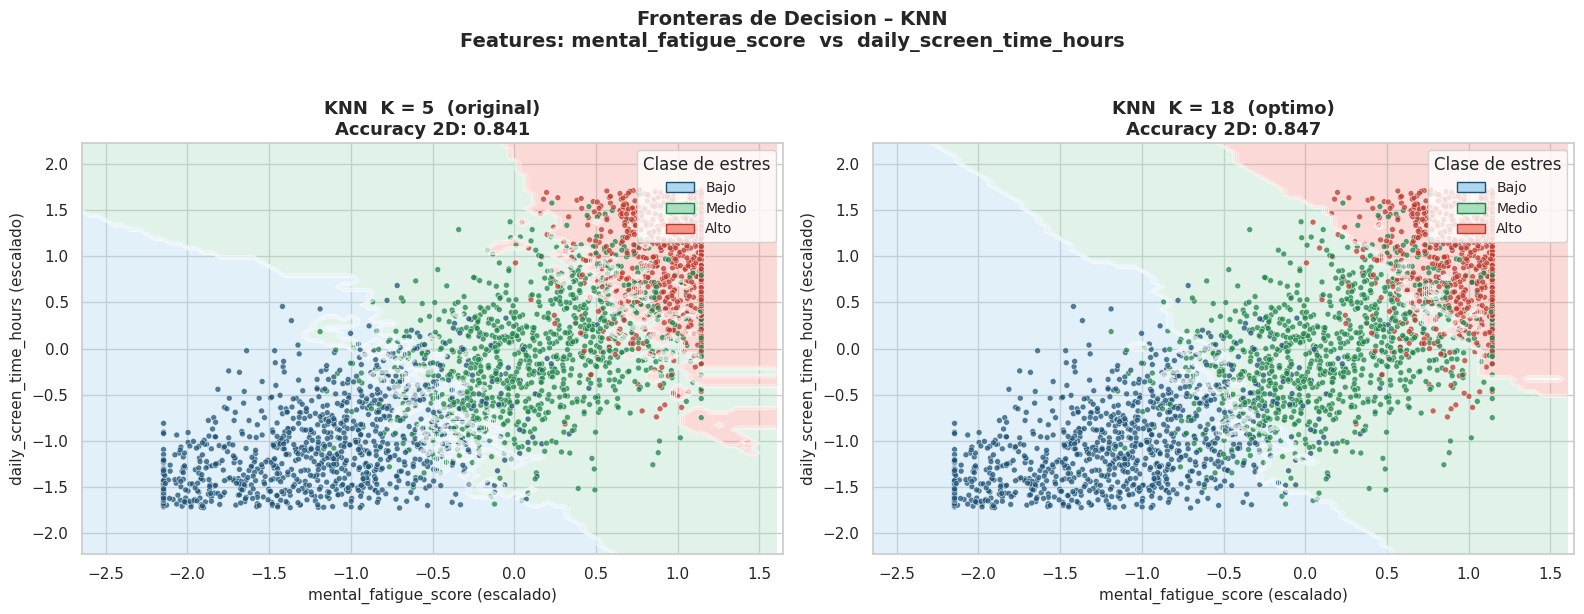


Nota: la accuracy 2D es menor que la del modelo completo (12 features).
La frontera es una proyeccion ilustrativa, no el modelo final.


In [ ]:
# ── Fronteras de Decisión – KNN ───────────────────────────────────────────────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

feat1 = 'mental_fatigue_score'
feat2 = 'daily_screen_time_hours'

idx1 = list(X.columns).index(feat1)
idx2 = list(X.columns).index(feat2)

X_2d_train = X_train_c_sc[:, [idx1, idx2]]
X_2d_test  = X_test_c_sc[:, [idx1, idx2]]

class_labels = ['Bajo', 'Medio', 'Alto']
colors_bg    = ['#AED6F1', '#A9DFBF', '#F1948A']
colors_pt    = ['#1A5276', '#1E8449', '#C0392B']

h = 0.05
x_min, x_max = X_2d_train[:, 0].min() - 0.5, X_2d_train[:, 0].max() + 0.5
y_min, y_max = X_2d_train[:, 1].min() - 0.5, X_2d_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, k, title in zip(axes,
                         [5, best_k],
                         [f'KNN  K = 5  (original)', f'KNN  K = {best_k}  (optimo)']):

    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d_train, y_train_c)

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(colors_bg)
    cmap_pt = ListedColormap(colors_pt)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.7)

    scatter = ax.scatter(
        X_2d_test[:, 0], X_2d_test[:, 1],
        c=y_test_c, cmap=cmap_pt,
        edgecolors='white', linewidths=0.4,
        s=18, alpha=0.75
    )

    acc_2d = knn_2d.score(X_2d_test, y_test_c)

    ax.set_title(f'{title}\nAccuracy 2D: {acc_2d:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{feat1} (escalado)', fontsize=11)
    ax.set_ylabel(f'{feat2} (escalado)', fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    legend_elements = [Patch(facecolor=colors_bg[i], edgecolor=colors_pt[i],
                             label=class_labels[i]) for i in range(3)]
    ax.legend(handles=legend_elements, title='Clase de estres',
              loc='upper right', fontsize=10)

plt.suptitle(
    f'Fronteras de Decision – KNN\nFeatures: {feat1}  vs  {feat2}',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print('\nNota: la accuracy 2D es menor que la del modelo completo (12 features).')
print('La frontera es una proyeccion ilustrativa, no el modelo final.')



### Interpretacion – Fronteras de Decision

- Cada **region coloreada** representa el espacio que KNN asigna a una clase de estres (azul = Bajo, verde = Medio, rojo = Alto).
- Las **lineas blancas** son las fronteras entre regiones — donde el modelo cambia de clase predicha.
- Los **puntos** son los datos reales de test, coloreados segun su clase verdadera. Los puntos que caen en una region del color equivocado son errores del modelo.
- **K=5 (izquierda):** la frontera es mas irregular y con mas islas — el modelo reacciona demasiado al ruido local (overfitting).
- **K=18 (derecha):** la frontera es mas suave y continua — generaliza mejor, lo que explica su mayor accuracy en test (85.6% vs 82.5%).
- Se observa que `mental_fatigue_score` (eje X) tiene **mayor poder discriminativo**: a medida que aumenta, las clases pasan claramente de Bajo a Medio a Alto.
- `daily_screen_time_hours` (eje Y) refina la clasificacion pero tiene menos peso individual.


### 16. Explicación Conceptual (tipo docente)

---

### 🧠 ¿Qué hace la Regresión Lineal?

Imagina que quieres predecir cuánto pesará un pastel según cuánta harina usaste. La regresión lineal traza la **línea recta que mejor se ajusta** a los datos históricos. Luego, para cualquier cantidad de harina nueva, la línea te da una predicción de peso. En nuestro caso, la "harina" son las horas de sueño y el tiempo de pantalla, y el "peso" es el nivel de estrés numérico.

---

### 🧠 ¿Qué hace la Regresión Logística?

A pesar del nombre, no predice un número: predice **a cuál categoría pertenece algo**. Es como un médico que, basado en tus síntomas, decide si tienes fiebre baja, media o alta. Usa una función matemática (la sigmoide) para convertir números en probabilidades, y elige la categoría con mayor probabilidad.

---

### 🧠 ¿Qué hace KNN?

KNN significa "K vecinos más cercanos". Cuando quieres clasificar a una persona nueva, el modelo **busca las K personas más parecidas** en los datos históricos y ve qué nivel de estrés tuvieron ellas. Si 4 de 5 vecinos tenían estrés alto, predice estrés alto. Es como preguntar a tus amigos más parecidos a ti cómo les fue.

---

### 🧠 ¿Qué hace Naive Bayes?

Naive Bayes usa el **teorema de probabilidad de Bayes**. Para cada categoría, calcula "¿qué tan probable es que una persona con estas características tenga este nivel de estrés?". La "ingenuidad" (naive) viene de asumir que todas las variables son independientes entre sí, lo que simplifica mucho el cálculo. Es como decir: el sueño y el tiempo de pantalla son factores separados, sin relación entre ellos.

---

### 🔍 ¿Cómo se comparan?

| Modelo | Tipo | Necesita escalar | Explica "por qué" | Velocidad |
|---|---|---|---|---|
| Regresión Lineal | Regresión | Sí | Sí (coeficientes) | Muy rápido |
| Regresión Logística | Clasificación | Sí | Sí (coeficientes) | Rápido |
| KNN | Clasificación | Sí (obligatorio) | No | Lento en predicción |
| Naive Bayes | Clasificación | No estrictamente | Parcialmente | Muy rápido |

### 17. Conclusiones

### ¿Qué aprendimos?
- Las variables de sueño y tiempo de pantalla tienen una relación clara con el nivel de estrés. En particular, `mental_fatigue_score` fue el predictor más fuerte (coeficiente 1.58), seguido de `daily_screen_time_hours` (0.68) y `sleep_quality_score` (-0.58, relación inversa: mayor calidad de sueño → menor estrés).
- El proceso de ML no es solo código: requiere entender el problema, preparar bien los datos e interpretar los resultados en contexto.
- La elección del modelo depende del tipo de problema: si la variable objetivo es numérica continua, usamos regresión; si es categórica, usamos clasificadores.

### ¿Qué modelo funcionó mejor?
- **Regresión Logística** fue el mejor clasificador con un **Accuracy de 88.8%** y un **F1-score ponderado de 0.8877**, superando a Naive Bayes (88.4% / 0.8837) y KNN con K=5 (82.5% / 0.8237).
- La Regresión Logística mostró especial fortaleza en las clases extremas: 92% de F1 en estrés Bajo y 92% en estrés Alto. La clase Medio fue la más difícil para todos los modelos (F1 ~0.83), lo cual es esperable ya que es la frontera entre los otros dos grupos.
- Sorprendentemente, **Naive Bayes** quedó en segundo lugar muy cerca de la Regresión Logística, a pesar de asumir independencia entre variables que claramente están correlacionadas (como `mental_fatigue_score` y `stress_level`).
- **KNN con K=5** fue el de menor rendimiento entre los clasificadores, aunque mejoró significativamente al ajustar a **K=18** (Accuracy 85.6% / F1 0.8549), lo que confirma que K=5 era demasiado pequeño para este dataset.
- La **Regresión Lineal** obtuvo un **R² de 0.9416**, lo que indica que el modelo explica el 94.2% de la varianza del nivel de estrés numérico. Con un RMSE de 0.6628 sobre una escala de 1 a 10, el error promedio es muy bajo y el modelo es excelente para predicción continua.

### Limitaciones del trabajo
- La variable objetivo fue categorizada artificialmente usando percentiles 33/66, lo cual puede introducir arbitrariedad en los límites de cada clase. Esto explica parcialmente por qué la clase Medio fue la más difícil de predecir correctamente.
- Los modelos no fueron optimizados con búsqueda exhaustiva de hiperparámetros (GridSearchCV, validación cruzada completa).
- La columna `user_id` fue incluida como feature, lo cual no aporta información predictiva real y debería eliminarse en un trabajo más riguroso.

### Posibles mejoras futuras
- Eliminar `user_id` del conjunto de features, ya que es un identificador sin valor predictivo.
- Aplicar validación cruzada k-fold para estimaciones más robustas del rendimiento real.
- Explorar modelos más potentes como Random Forest o XGBoost.
- Balancear las clases si hay desbalance significativo usando SMOTE u otras técnicas (en este dataset las clases estaban casi balanceadas: ~4950 / ~4953 / ~5095).


## 18. Autoevaluación del Trabajo

**¿Qué fue lo más difícil?**  
El mayor reto fue asegurar que el escalado fuera correcto para cada tarea. Al principio usábamos un solo `scaler` para regresión y clasificación, lo que causaba que el `fit_transform` de clasificación sobreescribiera el de regresión. Detectar y corregir esto requirió entender bien cómo funciona el `StandardScaler` internamente. También fue desafiante decidir cómo categorizar `stress_level` de forma equilibrada sin introducir sesgo artificial.

**¿Qué fue lo más interesante?**  
Ver que `mental_fatigue_score` es por lejos el predictor más fuerte del estrés (coeficiente 1.58 en regresión lineal), incluso más que el tiempo de sueño o el tiempo de pantalla. También fue llamativo que Naive Bayes, siendo el modelo más simple en supuestos, lograra un rendimiento casi idéntico al de la Regresión Logística (88.4% vs 88.8%), a pesar de que las variables del dataset claramente no son independientes entre sí.

**¿Qué parte del trabajo entienden mejor ahora?**  
El impacto real del hiperparámetro K en KNN: al graficar accuracy train vs. test para K del 1 al 20, vimos claramente cómo K=1 sobreajusta el entrenamiento y cómo el rendimiento en test mejora hasta K=18. También quedó muy claro por qué escalar los datos es obligatorio en KNN, ya que sin normalización, variables con rangos distintos (como `notifications_received_per_day` de 20–299 vs. `sleep_duration_hours` de 4–9) distorsionarían completamente las distancias.

**¿Qué parte necesitan reforzar?**  
La validación cruzada k-fold para obtener estimaciones de rendimiento más confiables que un solo split 80/20. También sería importante aprender a usar `GridSearchCV` para optimizar hiperparámetros de forma sistemática, y profundizar en técnicas de balanceo de clases como SMOTE para casos donde las clases no estén tan equilibradas como en este dataset.
